
# Machine Learning Workflow: Survey Response Prediction

 **complete ML workflow** :

1. Data Collection 
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Train-Test Split
6. Model Training
7. Model Evaluation
8. Compare Multiple Classification Algorithms


Algorithms used:

- Logistic Regression
- Decision Tree
- Random Forest
- Naive Bayes
- Support Vector Machine
- Gradient Boosting
- XGBoost


## 1. Data Collection – Generate Dummy Survey Dataset

In [16]:

import numpy as np
import pandas as pd

np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "age": np.random.randint(18,65,n),
    "time_spent": np.random.normal(10,3,n),
    "pages_viewed": np.random.randint(1,20,n),
    "clicks": np.random.randint(1,15,n),
    "sentiment_score": np.random.uniform(-1,1,n)
})

# Engagement score
data["engagement_score"] = (
    data["time_spent"]*0.4 +
    data["pages_viewed"]*0.3 +
    data["clicks"]*0.3
)

# Target variable
data["survey_response"] = (
    data["engagement_score"] + data["sentiment_score"] > 12
).astype(int)

data.head()


,age,time_spent,pages_viewed,clicks,sentiment_score,engagement_score,survey_response
0,56,6.024771,16,2,-0.848946,7.809908,0
1,46,13.219156,3,12,0.655162,9.787663,0
2,32,13.141028,10,6,-0.144662,10.056411,0
3,60,9.114213,6,13,0.192128,9.345685,0
4,25,10.050655,18,10,-0.820696,12.420262,0


## 2. Data Cleaning & Preprocessing


In [17]:
# ==========================
# Data Cleaning & Preprocessing
# ==========================

# Check dataset shape
print("Dataset shape:", data.shape)

# Check data types
print("\nData Types:")
print(data.dtypes)


Dataset shape: (2000, 7)

Data Types:
age                   int32
time_spent          float64
pages_viewed          int32
clicks                int32
sentiment_score     float64
engagement_score    float64
survey_response       int64
dtype: object


In [18]:

# ---------------------------
# 1. Check missing values
# ---------------------------

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Basic statistics
print("\nBasic Statistics:")
data.describe()






Missing Values:
age                 0
time_spent          0
pages_viewed        0
clicks              0
sentiment_score     0
engagement_score    0
survey_response     0
dtype: int64

Basic Statistics:


,age,time_spent,pages_viewed,clicks,sentiment_score,engagement_score,survey_response
count,2000.00000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,41.31650,10.101200,10.165500,7.44950,-0.027619,9.324980,0.147000
std,13.46566,2.977101,5.464251,3.99818,0.572334,2.409493,0.354194
min,18.00000,-0.160441,1.000000,1.00000,-0.999518,2.243071,0.000000
25%,30.00000,8.078130,5.000000,4.00000,-0.522121,7.641977,0.000000
50%,42.00000,10.181396,10.000000,7.00000,-0.047189,9.351855,0.000000
75%,53.00000,12.169966,15.000000,11.00000,0.450935,11.095371,0.000000
max,64.00000,20.487633,19.000000,14.00000,0.998415,15.995053,1.000000


In [19]:


# ---------------------------
# 2. Remove duplicate rows
# ---------------------------
duplicates = data.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

data = data.drop_duplicates()




Duplicate Rows: 0


In [20]:
# ---------------------------
# 3. Validate data ranges
# ---------------------------

# Age should be between 18 and 65
data = data[(data["age"] >= 18) & (data["age"] <= 65)]

# Sentiment score should be between -1 and 1
data = data[(data["sentiment_score"] >= -1) & (data["sentiment_score"] <= 1)]

# Engagement score should be positive
data = data[data["engagement_score"] >= 0]



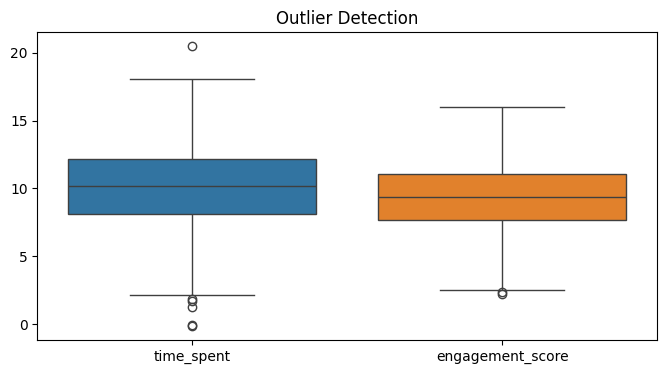

In [21]:
# ---------------------------
# 4. Outlier detection
# ---------------------------

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(data=data[["time_spent","engagement_score"]])
plt.title("Outlier Detection")
plt.show()

# Optional: Remove extreme outliers
data = data[data["time_spent"] < data["time_spent"].quantile(0.99)]



In [22]:
# ---------------------------
# 5. Data consistency check
# ---------------------------

# Check target distribution
print("\nTarget Variable Distribution:")
print(data["survey_response"].value_counts())

# ---------------------------
# Final cleaned dataset
# ---------------------------

print("\nFinal Dataset Shape:", data.shape)
data.head()


Target Variable Distribution:
survey_response
0    1698
1     282
Name: count, dtype: int64

Final Dataset Shape: (1980, 7)


,age,time_spent,pages_viewed,clicks,sentiment_score,engagement_score,survey_response
0,56,6.024771,16,2,-0.848946,7.809908,0
1,46,13.219156,3,12,0.655162,9.787663,0
2,32,13.141028,10,6,-0.144662,10.056411,0
3,60,9.114213,6,13,0.192128,9.345685,0
4,25,10.050655,18,10,-0.820696,12.420262,0


## 3. Exploratory Data Analysis (EDA)

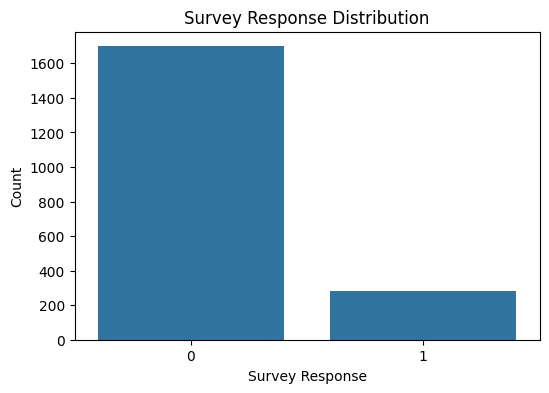

In [23]:
# Target Variable Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="survey_response", data=data)
plt.title("Survey Response Distribution")
plt.xlabel("Survey Response")
plt.ylabel("Count")
plt.show()




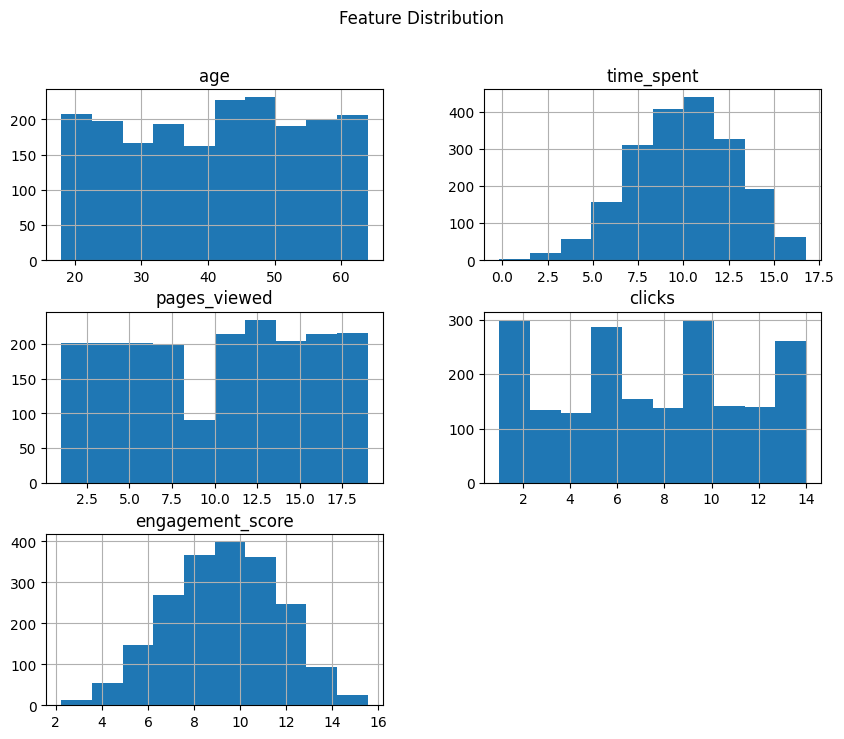

In [24]:

# Target Variable Distribution

data[["age","time_spent","pages_viewed","clicks","engagement_score"]].hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()


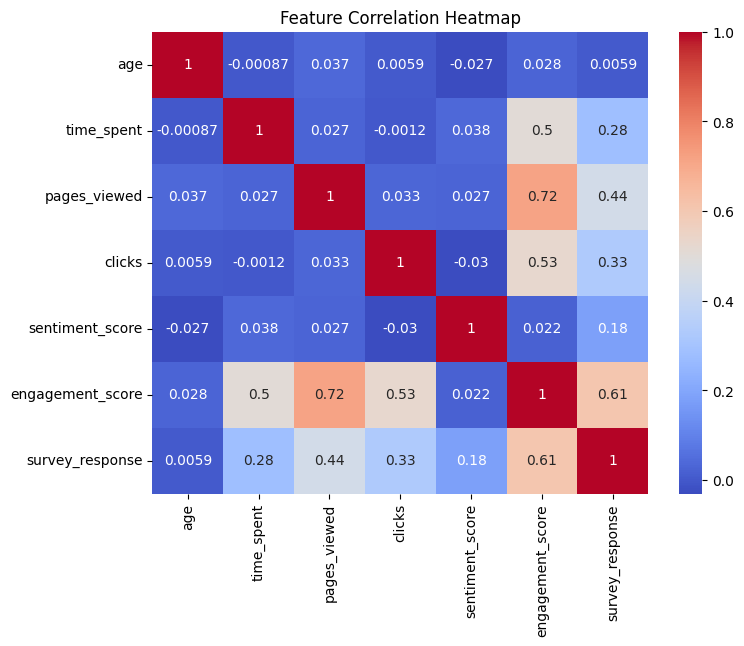

In [25]:

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()



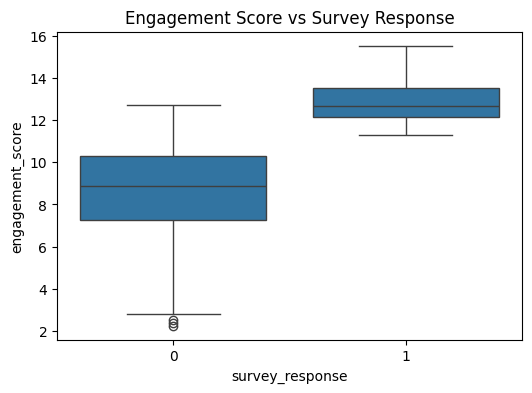

In [26]:
# Engagement Score vs Survey Response
plt.figure(figsize=(6,4))
sns.boxplot(x="survey_response", y="engagement_score", data=data)
plt.title("Engagement Score vs Survey Response")
plt.show()



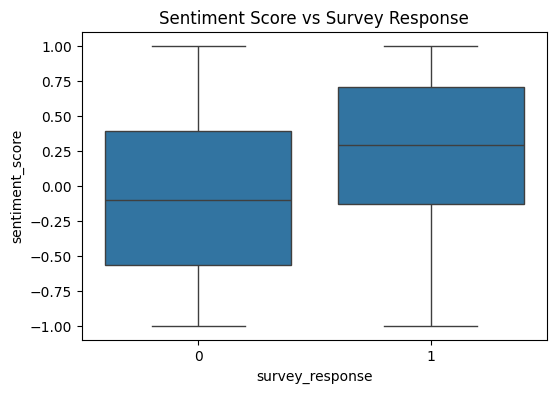

In [27]:

# Sentiment Score vs Survey Response
plt.figure(figsize=(6,4))
sns.boxplot(x="survey_response", y="sentiment_score", data=data)
plt.title("Sentiment Score vs Survey Response")
plt.show()



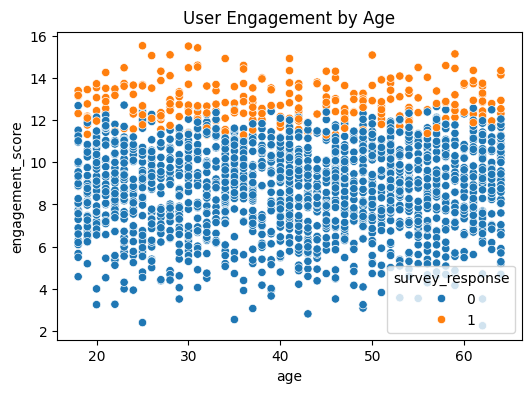

In [28]:

# Engagement vs Age (Behavior Insight)
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="engagement_score", hue="survey_response", data=data)
plt.title("User Engagement by Age")
plt.show()


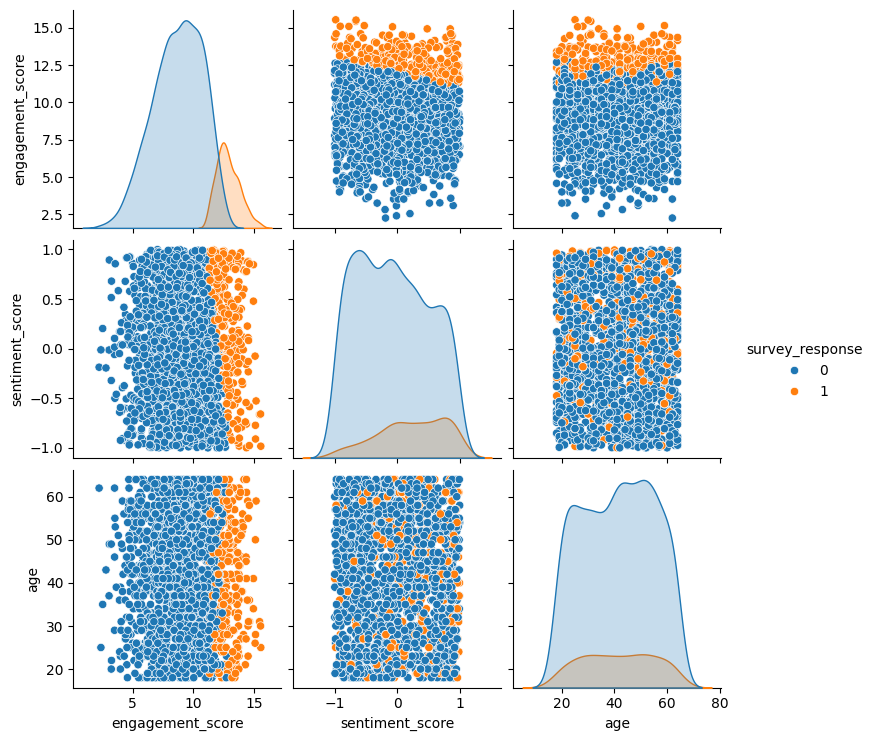

In [29]:

#Feature Importance Intuition (Before Modeling)
sns.pairplot(data[["engagement_score","sentiment_score","age","survey_response"]],
             hue="survey_response")
plt.show()

## 4. Feature Engineering

In [30]:

# Age Buckets
data["age_bucket"] = pd.cut(
    data["age"],
    bins=[18,25,35,45,55,65],
    labels=[0,1,2,3,4]
)

data.head()

# Normalize Engagement Components
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data[["time_spent_norm","pages_viewed_norm","clicks_norm"]] = scaler.fit_transform(
    data[["time_spent","pages_viewed","clicks"]]
)


# Feature Selection (Correlation Based)+

corr_matrix = data.corr()

corr_matrix["survey_response"].sort_values(ascending=False)

# Remove Redundant Features
data = data.drop(columns=["time_spent","pages_viewed","clicks"])

# Final Feature Dataset
X = data.drop("survey_response", axis=1)
y = data["survey_response"]

print("Final Feature Set Shape:", X.shape)




Final Feature Set Shape: (1980, 7)


## 5. Train-Test Split

In [31]:

from sklearn.model_selection import train_test_split

# Final Feature Dataset
X = data.drop("survey_response", axis=1)
y = data["survey_response"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)


Feature shape: (1980, 7)
Target shape: (1980,)


In [32]:
print("Missing values in dataset:")
print(X.isnull().sum())


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

import pandas as pd

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Missing values in dataset:
age                   0
sentiment_score       0
engagement_score      0
age_bucket           38
time_spent_norm       0
pages_viewed_norm     0
clicks_norm           0
dtype: int64
Before SMOTE:
survey_response
0    1358
1     226
Name: count, dtype: int64

After SMOTE:
survey_response
0    1358
1    1358
Name: count, dtype: int64


## 6. Model Training

Logistic Regression

Logistic Regression is a classification algorithm used to predict the probability of a binary outcome such as yes/no or 0/1.
It uses a logistic function to model the relationship between input features and the target variable.

Decision Tree

Decision Tree is a rule-based algorithm that splits data into branches based on feature values.
It makes predictions by following a sequence of decisions similar to a flowchart.

Random Forest

Random Forest is an ensemble algorithm that combines multiple decision trees to improve prediction accuracy.
The final prediction is made by aggregating the results of all trees.

Naive Bayes

Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem.
It assumes that features are independent and is commonly used for text classification problems.

Support Vector Machine (SVM)

SVM is a classification algorithm that separates data into classes using the best possible boundary called a hyperplane.
It tries to maximize the margin between different classes for better classification.

Gradient Boosting

Gradient Boosting builds models sequentially where each new model corrects the errors made by the previous one.
It improves prediction accuracy by combining multiple weak models.

XGBoost

XGBoost is an optimized implementation of gradient boosting designed for speed and performance.
It is widely used in machine learning competitions and real-world applications due to its high accuracy.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = []

for name, model in models.items():
    
    model.fit(X_train_balanced, y_train_balanced)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, f1])
    
    print(name)
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-------------")





Logistic Regression
Accuracy: 0.9873737373737373
F1 Score: 0.9572649572649573
Confusion Matrix:
[[335   5]
 [  0  56]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       340
           1       0.92      1.00      0.96        56

    accuracy                           0.99       396
   macro avg       0.96      0.99      0.97       396
weighted avg       0.99      0.99      0.99       396

-------------
Decision Tree
Accuracy: 0.9823232323232324
F1 Score: 0.9401709401709402
Confusion Matrix:
[[334   6]
 [  1  55]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       340
           1       0.90      0.98      0.94        56

    accuracy                           0.98       396
   macro avg       0.95      0.98      0.96       396
weighted avg       0.98      0.98      0.98       396

-------------
Random Forest
Accuracy: 0.97727272727272

## 7. Model Comparison

In [34]:

results_df = pd.DataFrame(results,columns=["Model","Accuracy","F1 Score"])
results_df.sort_values(by="F1 Score",ascending=False)


,Model,Accuracy,F1 Score
6,XGBoost,0.992424,0.973913
0,Logistic Regression,0.987374,0.957265
5,Gradient Boosting,0.982323,0.941176
1,Decision Tree,0.982323,0.940171
2,Random Forest,0.977273,0.923077
3,Naive Bayes,0.926768,0.785185
4,SVM,0.883838,0.708861


Accuracy: 0.9924242424242424
F1 Score: 0.9739130434782609
Confusion Matrix:
[[337   3]
 [  0  56]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       340
           1       0.95      1.00      0.97        56

    accuracy                           0.99       396
   macro avg       0.97      1.00      0.98       396
weighted avg       0.99      0.99      0.99       396

-------------


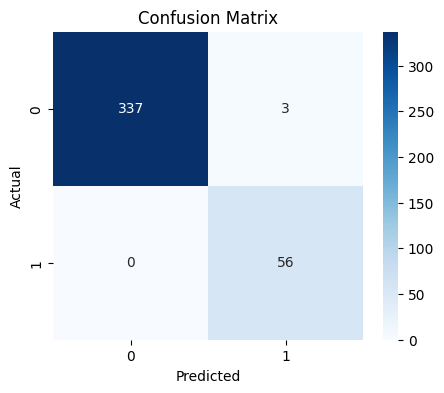

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

best_model = models["XGBoost"]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)



acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("Accuracy:", acc)
print("F1 Score:", f1)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("-------------")

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
import pandas as pd

# Convert X_test to DataFrame if it is not already
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Create dataframe with actual and predicted values
results_df = X_test_df.copy()
results_df["Actual_Response"] = y_test.values
results_df["Predicted_Response"] = y_pred

# Show results
results_df.head()

,age,sentiment_score,engagement_score,age_bucket,time_spent_norm,pages_viewed_norm,clicks_norm,Actual_Response,Predicted_Response
0,43.0,0.461029,7.854086,2.0,0.859129,0.222222,0.076923,0,0
1,48.0,0.986327,10.139724,3.0,0.709348,0.833333,0.076923,0,0
2,62.0,0.103657,3.514102,4.0,0.439775,0.000000,0.000000,0,0
3,40.0,-0.244406,10.929079,2.0,0.382922,0.722222,1.000000,0,0
4,50.0,0.208348,7.213244,3.0,0.498713,0.611111,0.000000,0,0



## 8. Model Deployment Concept

In production we would:

1. Save best model
2. Register in MLflow
3. Deploy using API (FastAPI)
4. Containerize with Docker
5. Scale using Kubernetes
6. Monitor drift
